# Loading Data 


In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,LabelEncoder   

In [4]:
df = pd.read_csv('Mall_Customers.csv')
print('Head of the DataFrame:')
print(df.head())

Head of the DataFrame:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe() 

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Visualization

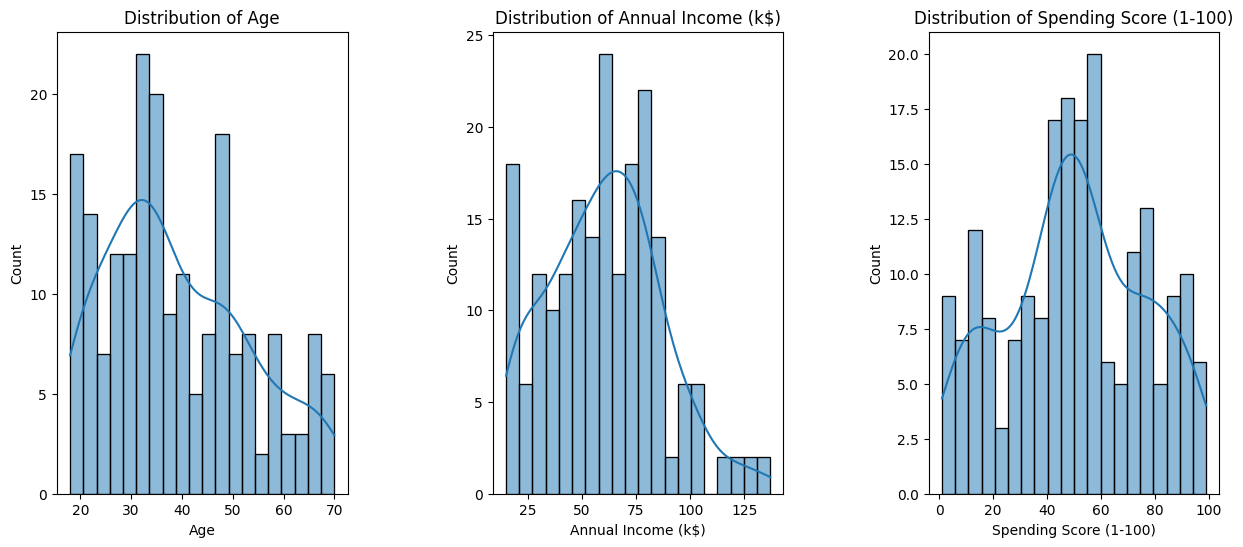

In [7]:

plt.figure(figsize=(15, 6))

n = 0
for x in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1, 3, n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    
    sns.histplot(df[x], bins=20, kde=True)
    
    plt.title(f'Distribution of {x}')

plt.show()

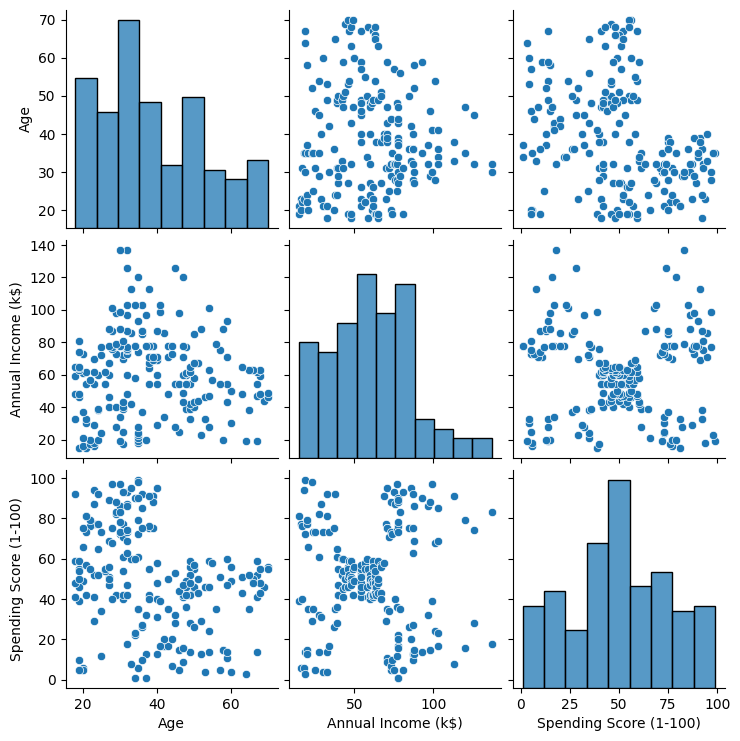

In [8]:
sns.pairplot(df[['Age','Annual Income (k$)','Spending Score (1-100)']])
plt.show()

# Model 

In [9]:
X = df.drop(['CustomerID', 'Gender', 'Age'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Choose the best N Cluster

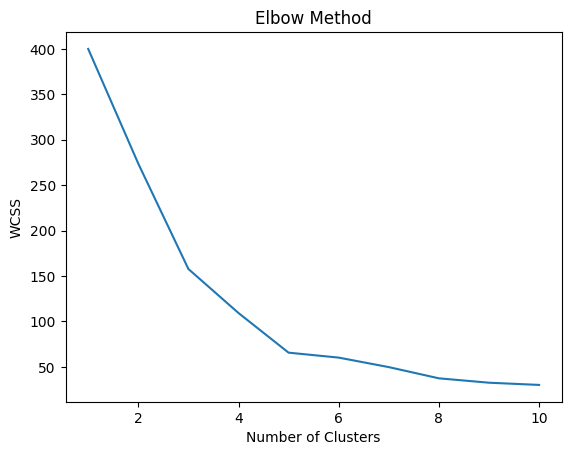

In [10]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## Best Model

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42, algorithm='elkan',max_iter=300)
kmeans.fit(X_scaled)



,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'elkan'


In [12]:
labels = kmeans.labels_
df['Cluster'] = labels
print('DataFrame with Cluster Labels:')
print(df.head())
print('\nCluster Value Counts:')
df['Cluster'].value_counts()

DataFrame with Cluster Labels:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  

Cluster Value Counts:


Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

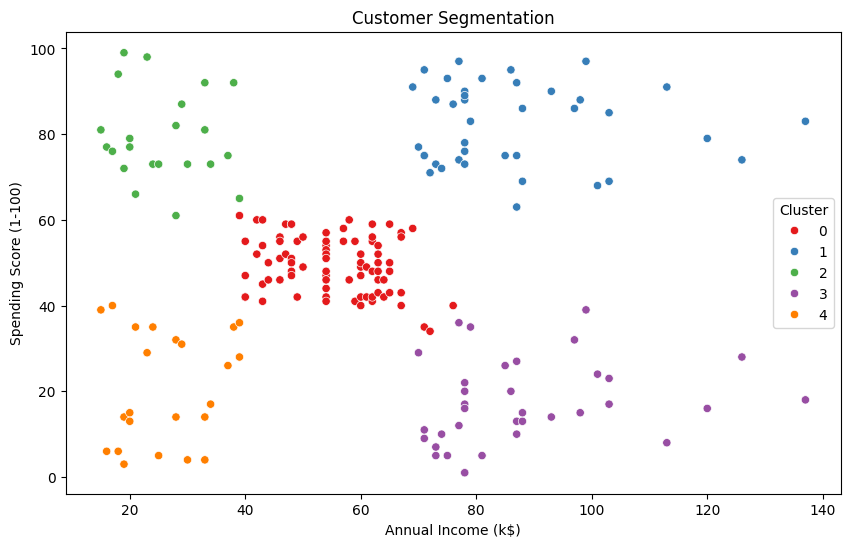

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segmentation")
plt.show()

In [14]:
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
# The code above performs customer segmentation using K-Means clustering on a dataset of mall customers.
# It includes data loading, exploratory data analysis, feature scaling, 
# determining the optimal number of clusters using the elbow method,
#  fitting the K-Means model, and visualizing the clusters.
#  Finally, it provides insights into the characteristics of each cluster by calculating the mean values of age,
#  annual income, and spending score for each cluster.

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


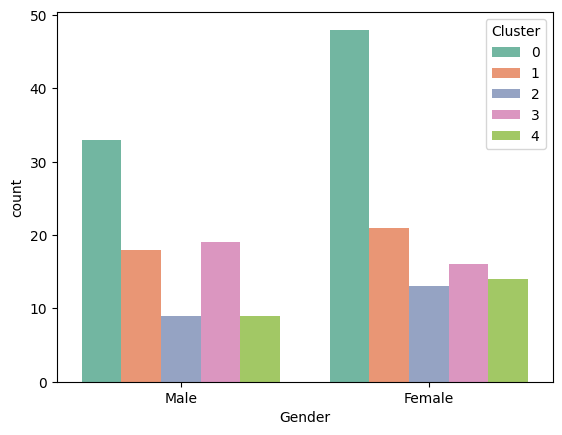

In [15]:
sns.countplot(x = 'Gender' , palette='Set2',hue='Cluster', data = df)
plt.show()